## Required Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from torchvision.datasets import MNIST  # using MNIST for simple demonstration
from sklearn.decomposition import PCA

## Data Transforms

In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((32, 32)), # for MNIST dataset, we resize the image to 32x32 for convenience purpose
        transforms.ToTensor(), # convert the image to a tensor  
    ]
)

# load the MNIST dataset
train_dataset = MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='../../data', train=False, download=True, transform=transform)

## Set the Device

In [3]:
# define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Exploring the Data

In [4]:
for image, label in train_dataset:
    print('-'*100)
    print('Basic Image Stats:')
    print(f'Image shape: {image.shape}.')
    print(f'Label: {label}.')
    print(f'Image min: {image.min()}.')
    print(f'Image max: {image.max()}.')
    print('-'*100)
    print(f'Image pixels:\n {image}.')
    print('-'*100)
    break

----------------------------------------------------------------------------------------------------
Basic Image Stats:
Image shape: torch.Size([1, 32, 32]).
Label: 5.
Image min: 0.0.
Image max: 0.9921568632125854.
----------------------------------------------------------------------------------------------------
Image pixels:
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]).
----------------------------------------------------------------------------------------------------


## The Vanilla Autoencoder

In [5]:
class Autoencoder(nn.Module):
    """A simple autoencoder model. The encoder network is a stack of linear layers with ReLU activation functions
    as nonlinearities. The autoencoder network is trained to learn a compressed representation of the data.
    """
    def __init__(self, bottleneck_size: int=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 32),
            nn.Sigmoid() # ensure the output is in the range [0, 1] for visualization and reconstruction
                         # to ensure the output is in the range [-1, 1], we can use nn.Tanh() instead of nn.Sigmoid()
        )
    
    def encode(self, x):
        """Encoder function to encode the image to a latent space.
        """
        return self.encoder(x)
    
    def decode(self, x):
        """Decoder function to decode the latent space to an image.
        """
        x = self.decoder(x)
        x = x.reshape(-1, 1, 32, 32) # reshape the output to the original image shape
        return x
    
    def forward(self, x):
        b, c, h, w = x.shape

        x = x.flatten(start_dim=1) # flatten the image to a 1D vector starting from the second dimension

        encoded = self.encode(x) # encode the image to a latent space
        decoded = self.decode(encoded) # decode the latent space to an image

        return encoded, decoded

### A Simple Forward Pass

In [6]:
model = Autoencoder()
rand = torch.randn(2, 1, 32, 32)
model(rand)

(tensor([[-0.0581, -0.0462],
         [-0.0206, -0.0501]], grad_fn=<AddmmBackward0>),
 tensor([[[[0.5151, 0.4958, 0.4660,  ..., 0.4712, 0.5124, 0.4984],
           [0.5249, 0.4765, 0.4659,  ..., 0.5199, 0.4760, 0.4871],
           [0.4686, 0.4839, 0.4920,  ..., 0.4874, 0.4770, 0.5035],
           ...,
           [0.5529, 0.4739, 0.5188,  ..., 0.4988, 0.5073, 0.4692],
           [0.5115, 0.4982, 0.4966,  ..., 0.4944, 0.4774, 0.5035],
           [0.4660, 0.4965, 0.4726,  ..., 0.4754, 0.4884, 0.4586]]],
 
 
         [[[0.5153, 0.4960, 0.4658,  ..., 0.4710, 0.5123, 0.4984],
           [0.5247, 0.4762, 0.4660,  ..., 0.5200, 0.4759, 0.4870],
           [0.4688, 0.4840, 0.4922,  ..., 0.4872, 0.4769, 0.5034],
           ...,
           [0.5526, 0.4741, 0.5189,  ..., 0.4988, 0.5073, 0.4692],
           [0.5114, 0.4984, 0.4967,  ..., 0.4943, 0.4775, 0.5032],
           [0.4662, 0.4963, 0.4726,  ..., 0.4756, 0.4884, 0.4588]]]],
        grad_fn=<ViewBackward0>))

## Training

In [7]:
def train(
    model: nn.Module,
    train_dataset: Dataset,
    test_dataset: Dataset,
    batch_size: int,
    training_iterations: int,
    eval_iterations: int
    ):

        print("Training the model...")
        print(model)

        model  = model.to(device)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        optimizer = optim.Adam(model.parameters(), lr=0.0005)

        train_loss = []
        eval_loss = []
        train_losses = []
        eval_losses = []

        encoded_data_per_eval = []

        pbar = tqdm(range(training_iterations), desc="Training")
        last_eval_loss = None

        train = True

        global_step = 0

        while train:
            model.train()
            for images, labels in train_loader:
                images = images.to(device)

                optimizer.zero_grad()
                
                encoded, recon = model(images)

                loss = torch.mean((images - recon) ** 2) # compute the mean squared error
                train_loss.append(loss.item())

                loss.backward()
                optimizer.step()

                if global_step % eval_iterations == 0:
                    model.eval()
                    encoded_evals = []

                    for images, labels in test_loader:

                        with torch.no_grad():
                            images = images.to(device)
                        
                        encoded, recon = model(images)

                        loss = torch.mean((images - recon) ** 2)
                        eval_loss.append(loss.item())

                        # store the encoded data and the labels
                        encoded, labels = encoded.cpu().flatten(1), labels.reshape(-1, 1)
                        encoded_evals.append(torch.cat((encoded, labels), axis=-1))
                    
                    encoded_data_per_eval.append(torch.concatenate(encoded_evals).detach())
                    
                    train_loss = np.mean(train_loss)
                    eval_loss = np.mean(eval_loss)
                    last_eval_loss = eval_loss
                    
                    train_losses.append(train_loss)
                    eval_losses.append(eval_loss)

                    print(f'training loss: {train_loss:.4f}, eval loss: {eval_loss:.4f}')
                    
                    # reset the loss values for the next evaluation
                    train_loss = []
                    eval_loss = []
                
                global_step += 1
                pbar.update(1)

                if global_step >= training_iterations:
                    print("Training complete.")
                    train = False
                    break
        
        # store the encoded data as numpy arrays for each evaluation
        encoded_data_per_eval = [i.numpy() for i in encoded_data_per_eval]  # convert tensors to numpy (avoids np.array deprecation with PyTorch)

        return model, train_losses, eval_losses, encoded_data_per_eval

In [8]:
# start with a fresh model
model = Autoencoder(bottleneck_size=2)

In [9]:
model, train_losses, eval_losses, encoded_data_per_eval = train(
    model,
    train_dataset,
    test_dataset,
    batch_size=64,
    training_iterations=5000,
    eval_iterations=250)

Training the model...
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

training loss: 0.2203, eval loss: 0.2197
training loss: 0.0768, eval loss: 0.0548
training loss: 0.0519, eval loss: 0.0496
training loss: 0.0469, eval loss: 0.0448
training loss: 0.0440, eval loss: 0.0433
training loss: 0.0424, eval loss: 0.0421
training loss: 0.0415, eval loss: 0.0408
training loss: 0.0401, eval loss: 0.0393
training loss: 0.0388, eval loss: 0.0385
training loss: 0.0382, eval loss: 0.0378
training loss: 0.0376, eval loss: 0.0373
training loss: 0.0371, eval loss: 0.0368
training loss: 0.0365, eval loss: 0.0364
training loss: 0.0363, eval loss: 0.0359
training loss: 0.0358, eval loss: 0.0355
training loss: 0.0354, eval loss: 0.0353
training loss: 0.0352, eval loss: 0.0352
training loss: 0.0348, eval loss: 0.0347
training loss: 0.0347, eval loss: 0.0346
training loss: 0.0342, eval loss: 0.0343
Training complete.


## Plot the Embedding Space through Training

Now we can write a function that takes in the `encoded_data_per_eval` from the training output, and create an animation of the embedding space to see how the neural network learns. Note that the first two columns of the `encoded_data_per_eval` denote the principal component axes where the model decides to place the embeddings, and the last column denotes the corresponding class labels of the embeddings.

In [10]:
print(encoded_data_per_eval[0])

[[ 0.07179434 -0.13717529  7.        ]
 [ 0.07257979 -0.11516142  2.        ]
 [ 0.07326623 -0.13008599  1.        ]
 ...
 [ 0.09326364 -0.10936093  4.        ]
 [ 0.07238226 -0.1284841   5.        ]
 [ 0.09542436 -0.11288264  6.        ]]


In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter

def generate_embedding_animation(
    encodings: np.ndarray | list[np.ndarray],
    title: str = "Autoencoder Embedding Space",
    *,
    output_path: str | None = None,
    eval_iterations: int = 250,
    fps: int = 4,
):
    """
    Generate a static plot or GIF of the embedding space.
    Pass a single array for a static plot, or a list of arrays for a GIF.
    """
    def _plot_frame(ax, data: np.ndarray, frame_title: str, x_lim=None, y_lim=None):
        df = pd.DataFrame(data, columns=["x", "y", "class"])
        df = df.sort_values(by="class")
        df["class"] = df["class"].astype(int).astype(str)
        for label, coordinates in df.groupby("class"):
            ax.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
        ax.set_title(frame_title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if x_lim is not None:
            ax.set_xlim(x_lim)
        if y_lim is not None:
            ax.set_ylim(y_lim)
        ax.legend()

    if isinstance(encodings, np.ndarray):
        # Single frame - static plot
        fig, ax = plt.subplots(figsize=(8, 6))
        _plot_frame(ax, encodings, title)
        plt.show()
    else:
        # List of frames - GIF
        path = output_path or "embedding_progression.gif"
        all_x = np.concatenate([d[:, 0] for d in encodings])
        all_y = np.concatenate([d[:, 1] for d in encodings])
        x_margin = (all_x.max() - all_x.min()) * 0.05 or 0.1
        y_margin = (all_y.max() - all_y.min()) * 0.05 or 0.1
        x_lim = (all_x.min() - x_margin, all_x.max() + x_margin)
        y_lim = (all_y.min() - y_margin, all_y.max() + y_margin)

        fig, ax = plt.subplots(figsize=(8, 6))

        def update(frame_idx: int):
            ax.clear()
            step = (frame_idx + 1) * eval_iterations
            _plot_frame(ax, encodings[frame_idx], f"Embedding Space at Step {step}", x_lim, y_lim)

        anim = FuncAnimation(fig, update, frames=len(encodings), interval=1000 // fps)
        anim.save(path, writer=PillowWriter(fps=fps))
        plt.close()
        print(f"GIF saved to {path}")

In [12]:
# Generate GIF of training progression
generate_embedding_animation(
    encoded_data_per_eval,
    output_path="embedding_progression.gif",
    eval_iterations=250,
)

GIF saved to embedding_progression.gif


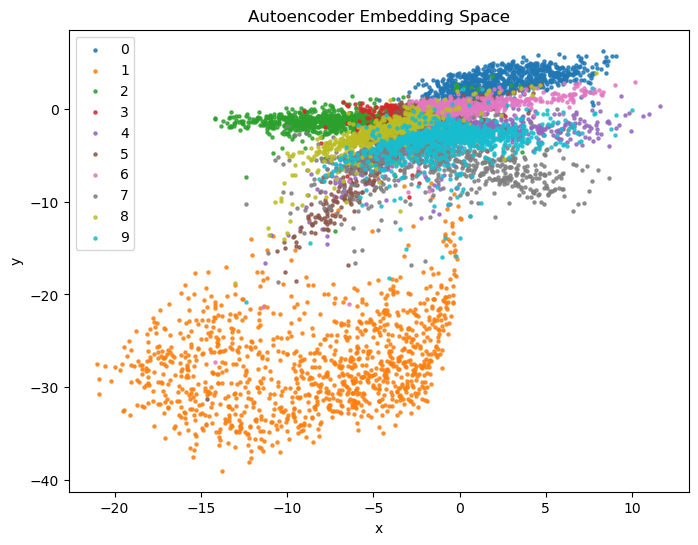

In [13]:
generate_embedding_animation(encoded_data_per_eval[-1], "Autoencoder Embedding Space")

The above plot demonstrates the compressed latent space of the model. If we take a look at the plot and the corresponding labels, we can see some effects of clustering here, for instance, the points representing "4"(purple) and "9" (blue) are very close to each other, coincide with their visual appearances.

Now let's see the progression.

![Embedding progression](embedding_progression.gif)

## A Linear Autoencoder is Just Another PCA

In [14]:
class LinearAutoencoder(nn.Module):
    def __init__(self, bottleneck_size: int=2):
        """
        A linear autoencoder with simple linear layers to compress and decompress the images.
        """
        super(LinearAutoencoder, self).__init__()

        self.encoder = nn.Linear(32 * 32, bottleneck_size)
        self.decoder = nn.Linear(bottleneck_size, 32 * 32)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        decoded = decoded.reshape(-1, 1, 32, 32) # reshape the output to the original image shape

        return encoded, decoded

In [15]:
model = LinearAutoencoder(bottleneck_size=2) # initialize the model

### Training the Linear Autoencoder

In [16]:
model, train_losses, eval_losses, encoded_data_per_eval = train(model, train_dataset, test_dataset, batch_size=64, training_iterations=25000, eval_iterations=250)

Training the model...
LinearAutoencoder(
  (encoder): Linear(in_features=1024, out_features=2, bias=True)
  (decoder): Linear(in_features=2, out_features=1024, bias=True)
)


Training:   0%|          | 0/25000 [00:00<?, ?it/s]

training loss: 0.2904, eval loss: 0.2785
training loss: 0.2184, eval loss: 0.1647
training loss: 0.1231, eval loss: 0.0937
training loss: 0.0777, eval loss: 0.0676
training loss: 0.0625, eval loss: 0.0594
training loss: 0.0576, eval loss: 0.0569
training loss: 0.0560, eval loss: 0.0560
training loss: 0.0554, eval loss: 0.0556
training loss: 0.0552, eval loss: 0.0554
training loss: 0.0550, eval loss: 0.0552
training loss: 0.0550, eval loss: 0.0551
training loss: 0.0547, eval loss: 0.0550
training loss: 0.0549, eval loss: 0.0548
training loss: 0.0543, eval loss: 0.0546
training loss: 0.0542, eval loss: 0.0544
training loss: 0.0542, eval loss: 0.0541
training loss: 0.0536, eval loss: 0.0539
training loss: 0.0538, eval loss: 0.0536
training loss: 0.0532, eval loss: 0.0533
training loss: 0.0530, eval loss: 0.0530
training loss: 0.0528, eval loss: 0.0526
training loss: 0.0524, eval loss: 0.0523
training loss: 0.0520, eval loss: 0.0520
training loss: 0.0516, eval loss: 0.0517
training loss: 0

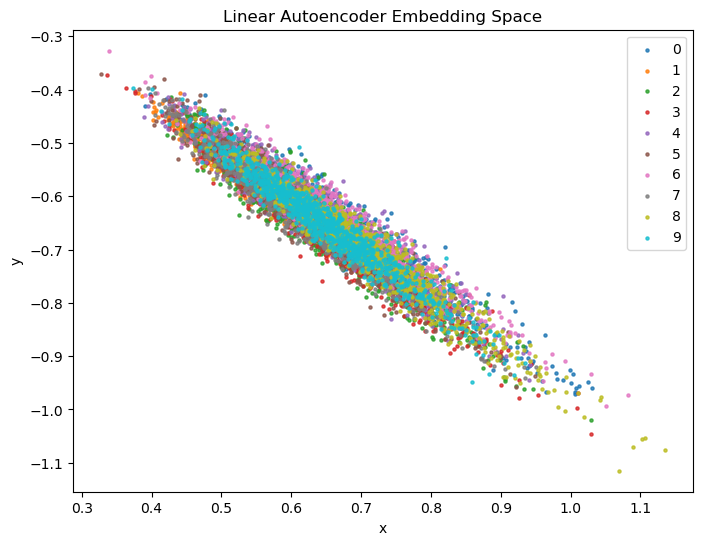

In [17]:
generate_embedding_animation(encoded_data_per_eval[3], "Linear Autoencoder Embedding Space")

### Compare to PCA

In [18]:
display(test_dataset[0])
display(test_dataset[0][0].shape)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 7)

torch.Size([1, 32, 32])

As from above, there are two entries of each data sample in the test dataset, with each image stored as a $1 \times 32 \times 32$ tensor.

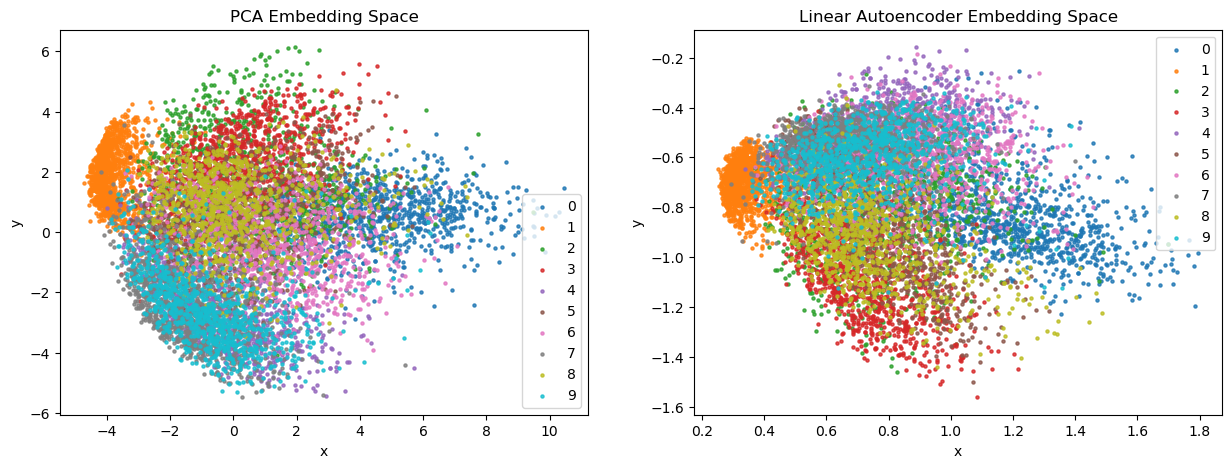

In [19]:
# convert the data in the test dataset to numpy arrays
data = torch.cat([d[0].flatten(1) for d in test_dataset], dim=0).numpy()
labels = np.array([test_sample[1] for test_sample in test_dataset]).reshape(-1, 1)

# compute PCA encodings (add label column so we have x, y, class like autoencoder encodings)
pca = PCA(n_components=2)
pca_encodings = pca.fit_transform(data)
pca_encodings = np.concatenate((pca_encodings, labels), axis=-1)
pca_encodings = pd.DataFrame(pca_encodings, columns=["x", "y", "class"])
pca_encodings = pca_encodings.sort_values(by="class")
pca_encodings["class"] = pca_encodings["class"].astype(int).astype(str)

# get the last row of Linear Autoencoder encodings
linear_autoencoder_encodings = encoded_data_per_eval[-1]
linear_autoencoder_encodings = pd.DataFrame(linear_autoencoder_encodings, columns=["x", "y", "class"])
linear_autoencoder_encodings = linear_autoencoder_encodings.sort_values(by="class")
linear_autoencoder_encodings["class"] = linear_autoencoder_encodings["class"].astype(int).astype(str)

# plot the PCA and Linear Autoencoder encodings
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# plot PCA encodings
for label, coordinates in pca_encodings.groupby("class"):
    ax1.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax1.set_title("PCA Embedding Space")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()

for label, coordinates in linear_autoencoder_encodings.groupby("class"):
    ax2.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax2.set_title("Linear Autoencoder Embedding Space")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

plt.show()

We can tell that the two embedding space looks very similar, and demonstrates we can essentially use linear autoencoder to mimic the behavior of the PCA model. Now let's check the principle components of PCA,

In [20]:
pca.components_

array([[ 8.2657975e-10,  7.9252405e-10, -1.7385084e-10, ...,
        -0.0000000e+00, -0.0000000e+00, -0.0000000e+00],
       [-1.1394464e-08, -2.0286421e-08,  2.7592120e-09, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
      shape=(2, 1024), dtype=float32)

In [21]:
 pca.components_.shape

(2, 1024)

Essentially it's like a transformation matrix that takes in a $1024$-dimensional vector and converts it to a $2$-dimensional vector, which is just like what we do in the linear autoencoder,

```python
class LinearAutoencoder(nn.Module):
    def __init__(self, bottleneck_size=2):
        super(LinearAutoencoder, self).__init__()
        self.encoder = nn.Linear(32 * 32, bottleneck_size)
        # weight matrix: 1024 x 2
        # ...
```

The principle components of PCA should be orthogonal,

In [25]:
principle_component1, principle_component2 = torch.tensor(pca.components_[0]), torch.tensor(pca.components_[1])

print(f'Angle between principle components: {torch.rad2deg(torch.acos(torch.dot(principle_component1, principle_component2)))} degrees')

print(f'Norm of principle component 1: {torch.norm(principle_component1):.4f}')
print(f'Norm of principle component 2: {torch.norm(principle_component2):.4f}')

Angle between principle components: 90.0 degrees
Norm of principle component 1: 1.0000
Norm of principle component 2: 1.0000


Now let's check the linear autoencoder,

In [26]:
model_weights = model.encoder.weight
model_weights.shape

torch.Size([2, 1024])

So yes, as expected, the model weight matrix of the linear autoencoder is of the same shape as the PCA transformation matrix.

In [27]:
weight_vector1, weight_vector2 = model_weights[0], model_weights[1]

print(f'Angle between weight vectors: {torch.rad2deg(torch.acos(torch.dot(weight_vector1, weight_vector2)))} degrees')

print(f'Norm of weight vector 1: {torch.norm(weight_vector1):.4f}')
print(f'Norm of weight vector 2: {torch.norm(weight_vector2):.4f}')


Angle between weight vectors: 88.87210845947266 degrees
Norm of weight vector 1: 0.3491
Norm of weight vector 2: 0.3558


So they are orthogonal but not necessarily unit norm. But we can make them so,

In [28]:
weight_vector1, weight_vector2 = weight_vector1 / torch.norm(weight_vector1), weight_vector2 / torch.norm(weight_vector2)

print(f'Angle between weight vectors: {torch.rad2deg(torch.acos(torch.dot(weight_vector1, weight_vector2)))} degrees')

print(f'Norm of weight vector 1: {torch.norm(weight_vector1):.4f}')
print(f'Norm of weight vector 2: {torch.norm(weight_vector2):.4f}')


Angle between weight vectors: 80.88094329833984 degrees
Norm of weight vector 1: 1.0000
Norm of weight vector 2: 1.0000


It's still almost orthogonal, and will get closer after training longer.